# 03 — 피처 엔지니어링 실험: 무엇이 정말 효과가 있나

[01](01_eda_report.ipynb) 과 [02](02_magic_group_structure.ipynb) 에서 세운 가설을
**AUC 로 직접 검증**한다. baseline 파이프라인의 구성요소를 하나씩 켜고 끄면서
"이게 정말 필요한가"를 측정한다.

## 왜 이런 노트북이 필요한가

캐글 노트북을 그대로 가져다 쓰면 **왜 그렇게 하는지 모른 채 코드가 늘어난다.**
baseline 에는 이런 것들이 들어 있다.

- 왜 하필 `std > 2` 인가? 1.5나 3이면 안 되나?
- KernelPCA 는 왜 쓰나? 없으면 얼마나 나빠지나?
- GMM 소속 확률을 **왜 5번 복사해서** 붙이나?
- `n_components=5` 는 어디서 나온 숫자인가?

이런 질문에 "원저자가 그렇게 했으니까"로 답하면 성장이 없다.
**하나씩 꺼 보고 AUC 를 재면 답이 나온다.** 이 과정을 **ablation study(절제 실험)** 라고 한다.

## 실험 설계 — 여기가 이 노트북에서 가장 중요한 부분

측정을 잘못하면 **잡음을 보고 잘못된 결론**을 내린다. 그래서 설계에 신경을 썼다.

| 결정 | 이유 |
|---|---|
| 평가 모델 = **QDA** 하나 | baseline 6개 중 가장 좋으면서 학습이 가볍다. 6개를 다 돌리면 실험 하나에 수십 분 |
| 대상 = **40개 그룹 고정** | 512개를 다 돌리면 설정 하나당 10분. 40개면 15초 |
| **모든 설정이 같은 그룹·같은 fold** 사용 | **대응 비교(paired comparison)** 가 가능해진다 (아래 설명) |
| **95% 신뢰구간**을 함께 보고 | 점수 차이가 잡음보다 큰지 판단하기 위해 |
| 두 가지 지표를 병기 | pooled AUC 와 그룹별 AUC 평균 (차이는 [04](04_model_diagnostics.ipynb) 3절에서 다룬다) |

**원리 — 왜 대응 비교(paired)가 중요한가**

설정 A 가 0.9482, 설정 B 가 0.9478 이라고 하자. B 가 더 나쁜가?
그룹마다 난이도가 다르므로, **어쩌다 A 가 쉬운 그룹에 걸렸을 수도** 있다.

대응 비교는 **같은 그룹에서 A 와 B 를 둘 다 재서 그 차이를 본다.**
그러면 그룹 난이도라는 공통 요인이 상쇄되고, **설정의 효과만 남는다.**
40개 그룹의 차이값으로 신뢰구간을 만들면 "이 차이가 0과 구분되는가"를 판정할 수 있다.

> ⚠️ 40개 그룹 · QDA 하나로 잰 값이므로, 512개 그룹 · 6개 모델 앙상블에 그대로 옮겨지지는 않는다.
> **방향성을 보는 실험**이라고 이해하자.

## 검증할 것
1. `std > 2` 임계값은 최선인가?
2. KernelPCA 는 정말 필요한가? 커널 선택은? 차원을 줄이면?
3. GMM 파생 피처의 기여는? `n_components` 는 5가 맞는가?
4. 같은 열을 5번 복사해 붙이는 "가중치 부여"가 효과가 있는가?
5. train+test 를 합쳐 변환을 적합하는 것(transductive)이 이득인가?
6. **pseudo labeling 을 붙이면 얼마나 오르는가?**

In [1]:
import gc
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from tqdm.auto import tqdm

from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

PROJECT_DIR = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "loader.py").exists()
)
sys.path.insert(0, str(PROJECT_DIR))
from data.loader import get_data_dir

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
_available = {f.name for f in font_manager.fontManager.ttflist}
for _font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"):
    if _font in _available:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = get_data_dir()
MAGIC_COL = "wheezy-copper-turtle-magic"
SAMPLE_MAGICS = list(range(40))      # 실험에 사용할 그룹 (고정 -> 모든 설정이 같은 조건)
N_SPLITS = 5
SEED = 0                             # fold 분할 시드도 고정 -> 대응 비교 가능
QDA_REG = 0.111                      # baseline 과 동일
print("data_dir:", DATA_DIR, "| 실험 그룹:", len(SAMPLE_MAGICS))

data_dir: C:\Users\jiho\.cache\kagglehub\competitions\original-instant-gratification | 실험 그룹: 40


## 0. 실험용 데이터 준비

40개 그룹만 있으면 되므로 해당 행만 남기고 나머지는 즉시 해제한다.
여기서는 float64 를 쓴다 — KernelPCA·GMM 같은 수치 계산이 들어가고 데이터도 작아서
정밀도를 아낄 이유가 없다. (02 노트북은 512개 그룹 전체를 다뤄서 float32 를 썼다.)

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
num_cols = [c for c in train_df.columns if c not in ("id", "target", MAGIC_COL)]
keep = train_df[MAGIC_COL].isin(SAMPLE_MAGICS).to_numpy()

Xtr_all = train_df.loc[keep, num_cols].to_numpy(dtype=np.float64)
ytr_all = train_df.loc[keep, "target"].to_numpy()
mtr_all = train_df.loc[keep, MAGIC_COL].to_numpy()
del train_df
gc.collect()

# test 피처도 필요하다. transductive 실험(6절)과 pseudo labeling(7절)에서 쓴다.
# test 의 '정답'은 쓰지 않는다 — 애초에 우리에게 없다.
test_df = pd.read_csv(DATA_DIR / "public_test.csv")
keep_te = test_df[MAGIC_COL].isin(SAMPLE_MAGICS).to_numpy()
Xte_all = test_df.loc[keep_te, num_cols].to_numpy(dtype=np.float64)
mte_all = test_df.loc[keep_te, MAGIC_COL].to_numpy()
del test_df
gc.collect()

TRAIN_IDX = {m: np.where(mtr_all == m)[0] for m in SAMPLE_MAGICS}
TEST_IDX = {m: np.where(mte_all == m)[0] for m in SAMPLE_MAGICS}
USEFUL = {
    m: np.where(Xtr_all[TRAIN_IDX[m]].std(axis=0, ddof=1) > 2.0)[0] for m in SAMPLE_MAGICS
}

print(f"train {Xtr_all.shape}, test {Xte_all.shape}")
print(f"그룹당 train {len(TRAIN_IDX[0])}행 / test {len(TEST_IDX[0])}행 / 유효 피처 {len(USEFUL[0])}개")

train (20475, 255), test (20485, 255)
그룹당 train 512행 / test 512행 / 유효 피처 46개


## 1. 실험 하네스 (harness)

**무엇을 하나** — baseline 파이프라인을 **옵션으로 분해한 함수** 하나를 만든다.
이후 모든 실험은 이 함수의 인자만 바꿔서 수행한다.

**왜 이렇게 하나** — 실험마다 코드를 복사해 조금씩 고치면
① 어디를 바꿨는지 추적이 안 되고 ② 실수로 두 군데가 달라져도 모른다.
**"바꾸고 싶은 것만 인자로 빼고 나머지는 완전히 동일하게"** 만드는 것이
비교 실험의 기본이다.

### baseline 파이프라인 복습 (그룹 하나에 대해)

```
① std > 2 인 컬럼만 선택          -> std_threshold
② KernelPCA(cosine) 로 좌표 변환   -> projection, n_component_ratio
③ GMM 적합 -> 소속확률·로그밀도를 파생 피처로 추가
                                  -> gmm_k, gmm_proba_rep, gmm_score_rep
④ 히스토그램 밀도 피처 추가        -> use_hist
⑤ StandardScaler                  -> scale
   (②③④는 train+test 를 합쳐 적합  -> transductive)
```

In [3]:
def select_cols(magic, std_threshold):
    """그룹 내 표준편차 기준으로 컬럼 선택. threshold<=0 이면 전체 255개를 쓴다."""
    if std_threshold <= 0:
        return np.arange(Xtr_all.shape[1])
    std = Xtr_all[TRAIN_IDX[magic]].std(axis=0, ddof=1)
    cols = np.where(std > std_threshold)[0]
    # 임계값이 너무 높아 하나도 안 뽑히면 전체를 쓴다 (실험이 죽지 않게 하는 안전장치)
    return cols if len(cols) else np.arange(Xtr_all.shape[1])


def build_features(
    magic,
    std_threshold=2.0,
    projection="kpca_cosine",   # None | "pca" | "kpca_cosine" | "kpca_rbf" | "kpca_poly"
    n_component_ratio=1.0,      # 투영 후 유지할 차원 비율 (1.0 = 차원 유지)
    gmm_k=5,                    # GMM 군집 수 (0 이면 GMM 미사용)
    gmm_proba_rep=5,            # 소속 확률(k열)을 몇 번 반복해 붙일지
    gmm_score_rep=3,            # 로그밀도(1열)를 몇 번 반복해 붙일지
    use_hist=True,              # 히스토그램 밀도 피처 사용 여부
    transductive=True,          # False 면 train 행으로만 변환을 적합
    scale=True,
    seed=SEED,
):
    """한 그룹의 (train 피처, test 피처, y, gmm 라벨) 을 만든다.

    반환하는 gmm 라벨은 CV 를 stratify 하는 데 쓴다 (baseline 과 동일).
    """
    cols = select_cols(magic, std_threshold)
    xtr = Xtr_all[np.ix_(TRAIN_IDX[magic], cols)]
    xte = Xte_all[np.ix_(TEST_IDX[magic], cols)]
    n_train = len(xtr)

    # train 과 test 를 세로로 붙여서 함께 변환한다.
    # fit_slice 가 transductive 여부를 결정하는 핵심 스위치:
    #   transductive=True  -> 전체(train+test)로 변환을 학습
    #   transductive=False -> train 부분만으로 학습 (변환은 양쪽 모두에 적용)
    allx = np.vstack([xtr, xte])
    fit_slice = slice(None) if transductive else slice(0, n_train)

    # ② 좌표 변환
    if projection:
        k = max(2, int(round(len(cols) * n_component_ratio)))
        if projection == "pca":
            model = PCA(n_components=k, random_state=seed)
        else:
            kernel = projection.split("_")[1]        # "kpca_cosine" -> "cosine"
            model = KernelPCA(n_components=k, kernel=kernel, random_state=seed)
        model.fit(allx[fit_slice])
        allx = model.transform(allx)

    # ③ GMM 파생 피처
    blocks = [allx]
    gmm_label = np.zeros(len(allx), dtype=int)
    if gmm_k and gmm_k > 0 and (gmm_proba_rep or gmm_score_rep):
        gmm = GaussianMixture(
            n_components=gmm_k, random_state=seed, max_iter=1000
        ).fit(allx[fit_slice])
        gmm_label = gmm.predict(allx)
        if gmm_proba_rep:
            proba = gmm.predict_proba(allx)          # (n, gmm_k) 소속 확률
            blocks += [proba] * gmm_proba_rep        # 같은 블록을 rep 번 반복해서 붙임
        if gmm_score_rep:
            score = gmm.score_samples(allx).reshape(-1, 1)   # 로그 우도(밀도)
            blocks += [score] * gmm_score_rep

    # ④ 히스토그램 밀도 피처
    if use_hist:
        blocks.append(hist_feature(allx, allx[fit_slice]).reshape(-1, 1))

    allx = np.hstack(blocks)
    if scale:
        allx = StandardScaler().fit_transform(allx)
    # 다시 train/test 로 잘라서 반환
    return allx[:n_train], allx[n_train:], ytr_all[TRAIN_IDX[magic]], gmm_label[:n_train]


def hist_feature(X, X_fit, bins=50):
    """변수별 50-bin 히스토그램 높이의 평균 (baseline 의 hist_model).

    각 값이 속한 구간의 '빈도'를 그 값의 점수로 삼는다 -> 조잡한 밀도 추정.
    """
    scores = np.empty(X.shape)
    for i in range(X.shape[1]):
        height, edge = np.histogram(X_fit[:, i], bins=bins)
        # searchsorted: 값이 어느 구간에 속하는지 이진 탐색으로 찾는다 (반복문보다 훨씬 빠름)
        idx = np.searchsorted(edge, X[:, i], side="left") - 1
        idx[idx >= bins] = -1
        scores[:, i] = height[idx]
    return scores.mean(axis=1)

이제 **설정 하나를 40개 그룹에서 평가하는 함수**와 **결과를 비교하는 함수**를 만든다.

**용어 — pooled AUC vs 그룹별 AUC 평균**
- **pooled**: 40개 그룹의 OOF 예측을 **한 줄로 모아** AUC 를 한 번 계산. 대회 지표와 같은 방식
- **그룹별 평균**: 그룹마다 AUC 를 재서 평균. 그룹 간 스케일 차이를 무시

둘은 **다른 값이 나온다.** 왜 다른지는 [04 노트북](04_model_diagnostics.ipynb) 3절의 주제다.
여기서는 둘 다 보여 주되, 대응 비교는 그룹별 값으로 한다(그래야 짝을 지을 수 있다).

In [4]:
def eval_config(name, magics=SAMPLE_MAGICS, stratify_by_gmm=True, progress=False, **kwargs):
    """설정 하나를 40개 그룹에서 평가. 그룹별 AUC 배열과 pooled AUC 를 반환.

    차원이 표본보다 커서 QDA 자체가 성립하지 않는 설정이 있다(예: 피처 선택을 끄는 경우).
    그런 그룹은 예외를 삼키지 않고 AUC 를 NaN 으로 남겨 '적용 불가'로 보고한다.
    (실패를 0.5 같은 값으로 채우면 '성능이 나쁜 설정'처럼 보여서 사실을 왜곡한다.)
    """
    per_group, pooled_pred, pooled_y, n_failed = [], [], [], 0
    it = tqdm(magics, desc=name, leave=False) if progress else magics
    for m in it:
        xtr, _, yg, gmm_label = build_features(m, **kwargs)
        oof = np.zeros(len(yg))

        # baseline 은 target 이 아니라 GMM 군집 라벨로 stratify 한다.
        # 군집이 너무 작으면 분할이 불가능하므로 target 으로 되돌린다.
        strat = gmm_label if stratify_by_gmm else yg
        if len(np.unique(strat)) < 2 or np.bincount(strat).min() < N_SPLITS:
            strat = yg

        splitter = StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED)
        failed = False
        for trn, val in splitter.split(xtr, strat):
            if len(np.unique(yg[trn])) < 2:      # 학습 fold 에 한 클래스만 있으면 학습 불가
                continue
            try:
                model = QuadraticDiscriminantAnalysis(reg_param=QDA_REG).fit(xtr[trn], yg[trn])
            except (np.linalg.LinAlgError, ValueError):
                failed = True
                break
            oof[val] = model.predict_proba(xtr[val])[:, 1]
        if failed:
            n_failed += 1
            per_group.append(np.nan)
            continue
        per_group.append(roc_auc_score(yg, oof))
        pooled_pred.append(oof)
        pooled_y.append(yg)

    per_group = np.array(per_group)
    pooled = (
        roc_auc_score(np.concatenate(pooled_y), np.concatenate(pooled_pred))
        if pooled_pred else np.nan
    )
    return {"name": name, "per_group": per_group, "pooled": pooled, "n_failed": n_failed}

In [5]:
def compare_table(results, reference=None):
    """대응 비교표.

    핵심은 마지막 두 열이다:
      - 'vs 기준'  : 같은 그룹끼리 뺀 차이의 평균 (그룹 난이도가 상쇄된다)
      - '95% CI'   : 그 차이의 신뢰구간. 0 을 포함하면 '차이를 입증하지 못했다'는 뜻
    """
    ref = reference if reference is not None else results[0]
    rows = []
    for r in results:
        if r.get("n_failed"):
            rows.append({
                "설정": r["name"], "pooled AUC": "적용 불가", "그룹평균 AUC": "적용 불가",
                f"vs {ref['name']}": "-",
                "95% CI": f"QDA 실패 {r['n_failed']}/{len(r['per_group'])} 그룹", "유의": "",
            })
            continue
        diff = r["per_group"] - ref["per_group"]        # 그룹별 짝지은 차이
        valid = diff[~np.isnan(diff)]
        # 표준오차 = 표준편차 / sqrt(n). 95% CI = 평균 ± 1.96 * 표준오차
        sem = valid.std(ddof=1) / np.sqrt(len(valid)) if len(valid) > 1 else 0.0
        rows.append({
            "설정": r["name"],
            "pooled AUC": round(r["pooled"], 5),
            "그룹평균 AUC": round(np.nanmean(r["per_group"]), 5),
            f"vs {ref['name']}": round(valid.mean(), 5) if len(valid) else np.nan,
            "95% CI": f"[{valid.mean() - 1.96 * sem:+.4f}, {valid.mean() + 1.96 * sem:+.4f}]",
            "유의": "O" if len(valid) and abs(valid.mean()) > 1.96 * sem and sem > 0 else "",
        })
    return pd.DataFrame(rows)


def best_of(results):
    """pooled AUC 가 가장 높은 설정 (적용 불가한 설정은 제외)."""
    valid = [r for r in results if not np.isnan(r["pooled"])]
    return max(valid, key=lambda r: r["pooled"])


def plot_sweep(results, xvalues, xlabel, title, ax=None):
    """스윕 결과를 pooled AUC + 그룹평균 ± 95% CI 로 그린다."""
    ax = ax or plt.gca()
    pooled = [r["pooled"] for r in results]
    means = np.array([np.nanmean(r["per_group"]) for r in results])
    ses = np.array([
        np.nanstd(r["per_group"], ddof=1) / np.sqrt(max(np.sum(~np.isnan(r["per_group"])), 1))
        for r in results
    ])
    ax.plot(xvalues, pooled, marker="o", color="#c44e52", label="pooled AUC")
    ax.errorbar(xvalues, means, yerr=1.96 * ses, marker="s", ms=4, lw=1,
                color="#4c72b0", alpha=0.8, capsize=3, label="그룹평균 ± 95% CI")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("AUC")
    ax.set_title(title)
    ax.legend(fontsize=8)
    return ax


# 기준선: baseline 원본 설정. 이후 모든 비교의 출발점이 된다.
baseline_cfg = dict(std_threshold=2.0, projection="kpca_cosine", n_component_ratio=1.0,
                    gmm_k=5, gmm_proba_rep=5, gmm_score_rep=3, use_hist=True,
                    transductive=True, scale=True)
BASELINE = eval_config("baseline(원본)", progress=True, **baseline_cfg)
print(f"baseline pooled AUC = {BASELINE['pooled']:.5f}, 그룹평균 = {BASELINE['per_group'].mean():.5f}")

baseline(원본):   0%|          | 0/40 [00:00<?, ?it/s]

baseline pooled AUC = 0.94826, 그룹평균 = 0.94541


## 2. `std > 2` 임계값은 최선인가?

**무엇을 하나** — 임계값을 0(전체 사용) ~ 3.5 로 바꿔 가며 AUC 를 잰다.

**왜 하나** — baseline 의 `2` 는 어디서 온 숫자인지 설명이 없다.
튜닝해야 할 하이퍼파라미터인지, 아니면 아무 값이나 써도 되는지 알아야 한다.

**가설** — [01 노트북](01_eda_report.ipynb) 4절에서 표준편차가 1 근처와 3.4~4.1 로
**완전히 갈라진 이봉 분포**임을 봤다. 두 봉우리 사이는 텅 비어 있으므로,
**그 빈 구간 어디를 잘라도 결과가 같아야 한다.**

**기대 결과** — 1.5 / 2.0 / 2.5 가 **완전히 동일한 값**. 양 극단에서만 무너진다.
그렇다면 이 하이퍼파라미터는 **튜닝할 필요가 없다**는 결론이 된다.

threshold sweep:   0%|          | 0/7 [00:00<?, ?it/s]

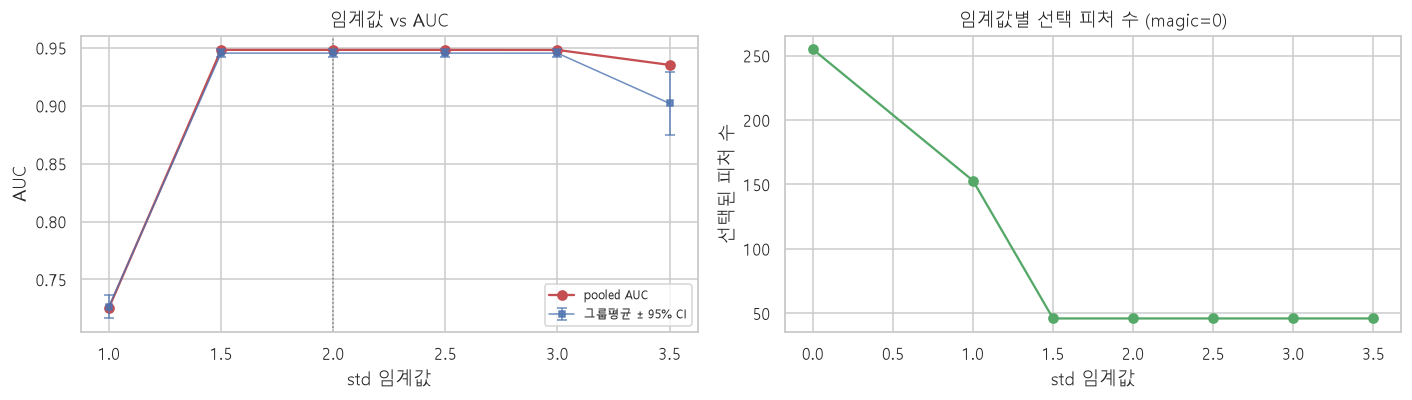

,설정,pooled AUC,그룹평균 AUC,vs std>2.0,95% CI,유의
0,std>0.0,적용 불가,적용 불가,-,QDA 실패 40/40 그룹,
1,std>1.0,0.72574,0.72666,-0.21875,"[-0.2303, -0.2072]",O
2,std>1.5,0.94826,0.94541,0.0,"[+0.0000, +0.0000]",
3,std>2.0,0.94826,0.94541,0.0,"[+0.0000, +0.0000]",
4,std>2.5,0.94826,0.94541,0.0,"[+0.0000, +0.0000]",
5,std>3.0,0.94817,0.94537,-0.00003,"[-0.0001, +0.0000]",
6,std>3.5,0.93524,0.902,-0.0434,"[-0.0702, -0.0166]",O


In [6]:
THRESHOLDS = [0.0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
thr_results = [
    eval_config(f"std>{t}", **{**baseline_cfg, "std_threshold": t})
    for t in tqdm(THRESHOLDS, desc="threshold sweep")
]

n_selected = [len(select_cols(0, t)) for t in THRESHOLDS]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
plot_sweep(thr_results, THRESHOLDS, "std 임계값", "임계값 vs AUC", ax=axes[0])
axes[0].axvline(2.0, color="gray", ls=":", lw=1)
axes[1].plot(THRESHOLDS, n_selected, marker="o", color="#55a868")
axes[1].set_title("임계값별 선택 피처 수 (magic=0)")
axes[1].set_xlabel("std 임계값")
axes[1].set_ylabel("선택된 피처 수")
plt.tight_layout()
plt.show()

display(compare_table(thr_results, reference=thr_results[3]))     # 기준 = std>2.0

> **관찰 — 예측대로.** 1.5 / 2.0 / 2.5 의 pooled AUC 가 **소수점 다섯째 자리까지 완전히 동일**하다
> (선택되는 피처 집합이 글자 그대로 같기 때문이다). 3.0 도 거의 같다.
>
> 양 극단은 무너진다.
> - **std>1.0** → 0.726. 잡음 피처(std≈1)가 섞여 들어와 QDA 의 공분산 추정이 망가진다
> - **std>3.5** → 0.935. 신호 피처 일부가 잘려 나간다
> - **std>0.0 (전체 255개)** → **QDA 자체가 성립 불가**
>
> ### 왜 "적용 불가"가 나오나 (초보자가 꼭 알아야 할 것)
>
> 피처 선택을 끄면 입력이 255 + 29 = **284차원**이 된다.
> 그런데 학습 fold 의 클래스당 표본은 **약 209행**뿐이다.
> QDA 는 클래스별 공분산 행렬을 추정해 **역행렬**을 구해야 하는데,
> **표본 수 < 차원 수**면 그 행렬이 특이(singular)해서 역행렬이 존재하지 않는다.
>
> 이것은 성능이 나쁜 게 아니라 **수학적으로 계산이 안 되는 것**이다.
> 이런 상황을 **"차원의 저주(curse of dimensionality)"** 라고 부른다.
>
> ### 결론
> **`std > 2` 는 튜닝 대상이 아니다.** 1.5~3.0 어디를 써도 같으므로
> 여기에 시간을 쓰는 것은 낭비다. 반면 **피처 선택 자체는 선택이 아니라 필수**다.

## 3. 투영(projection) — KernelPCA 는 필요한가?

**무엇을 하나** — 투영 방법(없음/PCA/커널 3종)과 유지 차원 비율을 스윕한다.

**용어 — KernelPCA**
PCA 는 데이터를 **선형**으로 회전시킨다. KernelPCA 는 데이터를 먼저 고차원으로 보낸 뒤
그곳에서 PCA 를 하는 것과 같은 효과를 내서, **비선형 구조를 펼 수 있다.**
`kernel="cosine"` 은 두 점 사이의 **각도**로 유사도를 재는 커널이다
(길이는 무시하고 방향만 본다).

**가설 1** — [02 노트북](02_magic_group_structure.ipynb) 4절에서 공분산이 full rank 임을 확인했다.
**중복 차원이 없으므로 차원을 줄이면 그만큼 정보가 사라져야 한다.**

**기대 결과 1** — ratio 를 낮출수록 AUC 가 단조 감소.

**가설 2** — KernelPCA 는 좌표계를 바꿔 QDA 가 다루기 좋은 형태로 만들어 줄 것이다.

**기대 결과 2** — kpca_cosine > 투영 없음. 얼마나 차이가 나는지가 관건이다.

projection:   0%|          | 0/5 [00:00<?, ?it/s]

n_components ratio:   0%|          | 0/4 [00:00<?, ?it/s]

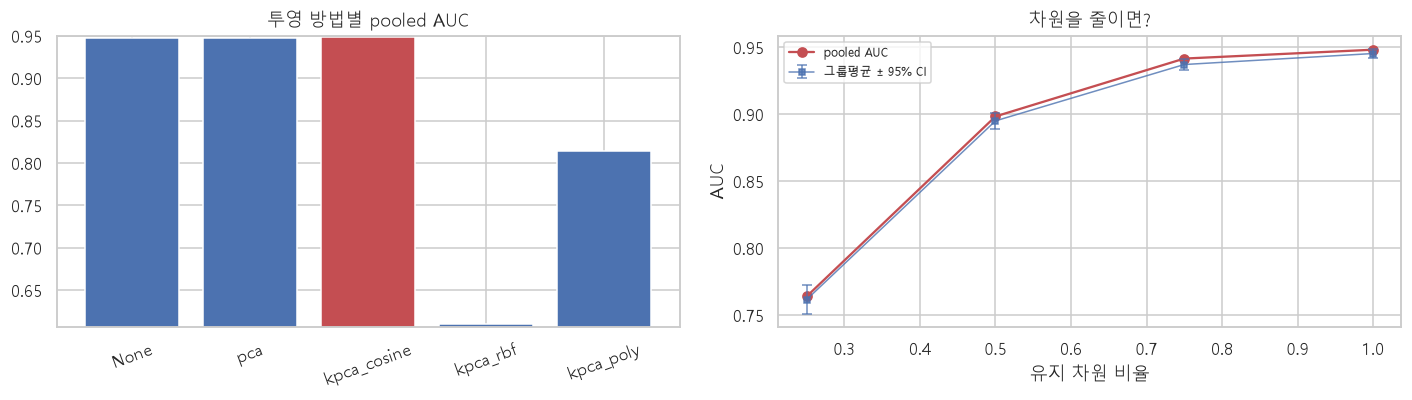

,설정,pooled AUC,그룹평균 AUC,vs kpca_cosine,95% CI,유의
0,None,0.94756,0.94458,-0.00082,"[-0.0030, +0.0013]",
1,pca,0.94754,0.94453,-0.00088,"[-0.0030, +0.0012]",
2,kpca_cosine,0.94826,0.94541,0.00000,"[+0.0000, +0.0000]",
3,kpca_rbf,0.61067,0.63183,-0.31358,"[-0.3231, -0.3041]",O
4,kpca_poly,0.81382,0.85880,-0.08661,"[-0.0951, -0.0781]",O


,설정,pooled AUC,그룹평균 AUC,vs ratio=1.0,95% CI,유의
0,ratio=0.25,0.76404,0.76170,-0.18371,"[-0.1953, -0.1721]",O
1,ratio=0.5,0.89843,0.89512,-0.05029,"[-0.0563, -0.0443]",O
2,ratio=0.75,0.94164,0.93719,-0.00821,"[-0.0109, -0.0055]",O
3,ratio=1.0,0.94826,0.94541,0.00000,"[+0.0000, +0.0000]",


In [7]:
PROJECTIONS = [None, "pca", "kpca_cosine", "kpca_rbf", "kpca_poly"]
proj_results = [
    eval_config(str(p), **{**baseline_cfg, "projection": p})
    for p in tqdm(PROJECTIONS, desc="projection")
]

RATIOS = [0.25, 0.5, 0.75, 1.0]     # 유지할 차원 비율 (1.0 = 줄이지 않음)
ratio_results = [
    eval_config(f"ratio={r}", **{**baseline_cfg, "n_component_ratio": r})
    for r in tqdm(RATIOS, desc="n_components ratio")
]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ok_proj = [r for r in proj_results if not np.isnan(r["pooled"])]
names = [r["name"] for r in ok_proj]
vals = [r["pooled"] for r in ok_proj]
colors = ["#c44e52" if n == "kpca_cosine" else "#4c72b0" for n in names]
axes[0].bar(names, vals, color=colors)
axes[0].set_ylim(min(vals) - 0.004, max(vals) + 0.002)
axes[0].set_title("투영 방법별 pooled AUC")
axes[0].tick_params(axis="x", rotation=20)

plot_sweep(ratio_results, RATIOS, "유지 차원 비율", "차원을 줄이면?", ax=axes[1])
plt.tight_layout()
plt.show()

display(compare_table(proj_results, reference=proj_results[2]))    # 기준 = kpca_cosine
display(compare_table(ratio_results, reference=ratio_results[-1])) # 기준 = ratio=1.0

> **관찰 1 — 차원 축소는 확실히 손해다(가설 확인).**
> ratio 0.75 → −0.0082, 0.5 → −0.0503, 0.25 → −0.1837. 모두 신뢰구간이 0을 포함하지 않는다(유의).
> 25%만 남기면 AUC 가 0.76 까지 떨어진다.
> **[02 노트북](02_magic_group_structure.ipynb) 4절의 "full rank 이므로 줄이면 손해"라는 예측이 정확히 맞았다.**
> 고유값 스펙트럼만 보고 실험 없이도 예측할 수 있었다는 점이 중요하다.
>
> **관찰 2 — KernelPCA 의 효과는 입증되지 않았다(가설 미확인).**
> kpca_cosine 이 투영 없음보다 **+0.0008 높지만 95% CI 가 [−0.0030, +0.0013]** 으로 0을 포함한다.
> 40개 그룹 표본으로는 **효과가 있다고 말할 수 없다.**
> "가장 높은 값 = 최선"이 아니라 **"차이가 잡음보다 큰가"** 로 판단해야 한다.
>
> **관찰 3 — 커널을 잘못 고르면 치명적이다.**
> rbf 0.611, poly 0.814. cosine 과 달리 이 커널들은 데이터를 크게 왜곡한다.
> **"KernelPCA 를 쓴다"가 아니라 "cosine 커널을 쓴다"가 핵심**이었던 셈이다.
>
> > **실무 교훈** — 효과가 입증되지 않은 구성요소(KernelPCA)를 남겨 둘지는 판단의 문제다.
> > 계산 비용이 크지 않고 해로울 근거도 없다면 유지해도 되지만,
> > **"이건 효과가 확인되지 않았다"는 사실을 알고 있는 것**과 모르는 것은 전혀 다르다.

## 4. GMM 파생 피처 — `n_components` 와 반복 복사

**무엇을 하나** — 두 가지를 스윕한다.
① GMM 군집 수 k (0 = GMM 미사용)
② 같은 열을 몇 번 복사해 붙이는지

**왜 하나** — [02 노트북](02_magic_group_structure.ipynb) 5절에서 **BIC 는 k=1 을 골랐다.**
그런데 baseline 은 k=5 를 쓴다. **AUC 기준으로는 무엇이 맞는지** 확인해야 한다.

그리고 baseline 코드에는 이런 줄이 있다.

```python
all_data = np.hstack([all_data, gmm_pred, gmm_pred, gmm_pred, gmm_pred, gmm_pred])
```

**같은 5열을 5번 붙여 25열을 만든다.** 왜? 원저자의 의도는 "이 피처에 가중치를 준다"였을 것이다.

**원리 — 열을 복사하면 정말 가중치가 되나?**
모델에 따라 다르다.
- **거리 기반 모델**(KNN, RBF-SVM): 유클리드 거리에 그 열이 5번 반영되므로 **실제로 가중치 효과가 있다**
- **QDA**: 완전히 상관된 열이 추가되면 공분산 행렬이 특이(singular)에 가까워진다.
  `reg_param` 정규화가 이를 막아 주지만, **가중치 효과는 기대하기 어렵다**

**기대 결과** — k 는 어딘가에 최적점이 있을 것. 반복 복사는 QDA 기준으로는 **효과가 없을 것.**

gmm k:   0%|          | 0/7 [00:00<?, ?it/s]

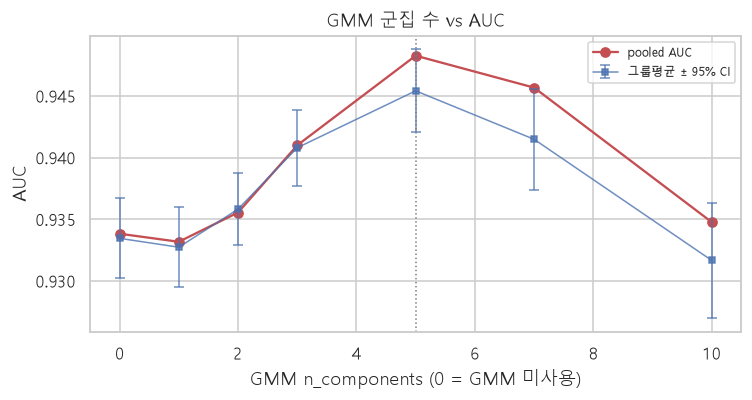

,설정,pooled AUC,그룹평균 AUC,vs k=5,95% CI,유의
0,k=0,0.93382,0.93345,-0.01196,"[-0.0146, -0.0093]",O
1,k=1,0.93317,0.93273,-0.01268,"[-0.0154, -0.0100]",O
2,k=2,0.93554,0.93581,-0.00959,"[-0.0120, -0.0072]",O
3,k=3,0.94099,0.94079,-0.00461,"[-0.0073, -0.0019]",O
4,k=5,0.94826,0.94541,0.00000,"[+0.0000, +0.0000]",
5,k=7,0.94566,0.94148,-0.00393,"[-0.0063, -0.0015]",O
6,k=10,0.93476,0.93166,-0.01375,"[-0.0173, -0.0102]",O


In [8]:
K_VALUES = [0, 1, 2, 3, 5, 7, 10]      # 0 = GMM 파생 피처를 아예 쓰지 않음
k_results = [
    eval_config(f"k={k}", **{**baseline_cfg, "gmm_k": k})
    for k in tqdm(K_VALUES, desc="gmm k")
]

plt.figure(figsize=(7, 3.8))
plot_sweep(k_results, K_VALUES, "GMM n_components (0 = GMM 미사용)", "GMM 군집 수 vs AUC")
plt.axvline(5, color="gray", ls=":", lw=1)
plt.tight_layout()
plt.show()

display(compare_table(k_results, reference=k_results[K_VALUES.index(5)]))

> **관찰 — BIC 와 AUC 가 정반대 답을 준다.**
>
> BIC 가 고른 k=1 은 k=5 보다 **0.0127 낮다.** 이 대회 규모에서 0.0127 은 매우 큰 차이다.
> k=0(GMM 미사용)도 −0.0120 이므로, **GMM 파생 피처 자체가 baseline 의 핵심 부품**이다.
>
> **[02 노트북](02_magic_group_structure.ipynb) 5절의 해석이 실험으로 확정되었다.**
> baseline 의 GMM 은 밀도 추정기가 아니라 **비선형 좌표 생성기**이고,
> 그 좌표의 개수(k)는 **분류 성능으로 정해야 할 하이퍼파라미터**다.
>
> k 를 5보다 키워도(7, 10) 나빠진다는 점도 의미가 있다.
> 좌표가 많을수록 좋은 게 아니라 **적당한 해상도가 있다.**
> 너무 적으면 구조를 못 담고, 너무 많으면 512행짜리 그룹에서 GMM 추정 자체가 불안정해진다.

repetition:   0%|          | 0/7 [00:00<?, ?it/s]

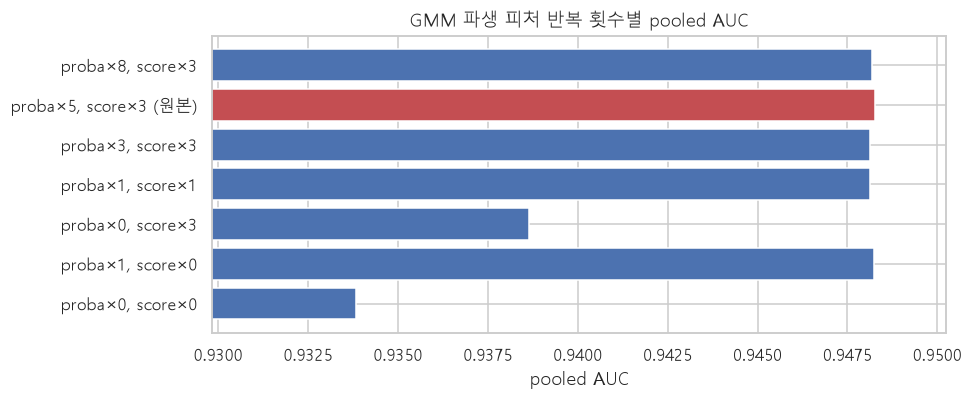

,설정,pooled AUC,그룹평균 AUC,"vs proba×5, score×3 (원본)",95% CI,유의
0,"proba×0, score×0",0.93382,0.93345,-0.01196,"[-0.0146, -0.0093]",O
1,"proba×1, score×0",0.94824,0.94585,0.00044,"[-0.0003, +0.0012]",
2,"proba×0, score×3",0.93865,0.93776,-0.00765,"[-0.0101, -0.0052]",O
3,"proba×1, score×1",0.94813,0.94562,0.00022,"[-0.0005, +0.0010]",
4,"proba×3, score×3",0.94812,0.94530,-0.00011,"[-0.0003, +0.0001]",
5,"proba×5, score×3 (원본)",0.94826,0.94541,0.00000,"[+0.0000, +0.0000]",
6,"proba×8, score×3",0.94818,0.94531,-0.00009,"[-0.0003, +0.0001]",


In [9]:
REP_CONFIGS = [
    ("proba×0, score×0", dict(gmm_proba_rep=0, gmm_score_rep=0)),   # GMM 파생 피처 없음
    ("proba×1, score×0", dict(gmm_proba_rep=1, gmm_score_rep=0)),   # 소속 확률만 1번
    ("proba×0, score×3", dict(gmm_proba_rep=0, gmm_score_rep=3)),   # 로그밀도만
    ("proba×1, score×1", dict(gmm_proba_rep=1, gmm_score_rep=1)),
    ("proba×3, score×3", dict(gmm_proba_rep=3, gmm_score_rep=3)),
    ("proba×5, score×3 (원본)", dict(gmm_proba_rep=5, gmm_score_rep=3)),
    ("proba×8, score×3", dict(gmm_proba_rep=8, gmm_score_rep=3)),
]
rep_results = [
    eval_config(name, **{**baseline_cfg, **kw})
    for name, kw in tqdm(REP_CONFIGS, desc="repetition")
]

plt.figure(figsize=(9, 3.8))
ok_rep = [r for r in rep_results if not np.isnan(r["pooled"])]
names = [r["name"] for r in ok_rep]
vals = [r["pooled"] for r in ok_rep]
colors = ["#c44e52" if "원본" in n else "#4c72b0" for n in names]
plt.barh(names, vals, color=colors)
plt.xlim(min(vals) - 0.004, max(vals) + 0.002)
plt.title("GMM 파생 피처 반복 횟수별 pooled AUC")
plt.xlabel("pooled AUC")
plt.tight_layout()
plt.show()

display(compare_table(rep_results, reference=rep_results[5]))

> **관찰 — 반복 복사는 효과가 없다(예측대로).**
> `proba×1` 로 줄여도 **+0.0004 (CI [−0.0003, +0.0012])** 로 원본과 구분되지 않는다.
> ×8 로 늘려도 마찬가지다. **즉 `hstack` 을 5번 하는 줄은 QDA 기준으로 아무 일도 하지 않는다.**
>
> 반면 소속 확률 자체는 중요하다. `proba×0` 이면 −0.0120 (유의).
> **"소속 확률을 넣느냐"는 중요하고, "몇 번 넣느냐"는 무관하다.**
>
> > **실무 교훈** — 인기 있는 캐글 노트북의 코드에도 **효과 없는 부분이 섞여 있다.**
> > 그대로 베끼면 그 부분까지 물려받는다. 측정해 보면 코드를 줄일 수 있다.
> > (단, 이 결론은 QDA 기준이다. 거리 기반인 KNN·SVM 에서는 다를 수 있다 — 아래 '직접 해보기' 참고)

## 5. 구성요소 하나씩 끄기 (ablation study)

**무엇을 하나** — baseline 에서 요소를 **하나씩만** 제거해 AUC 변화를 잰다.

**왜 하나** — 지금까지는 요소별로 따로 봤다. 여기서는 **같은 기준선에서 한 번에 비교**해서
**어떤 요소가 얼마나 기여하는지 순위**를 매긴다.

**읽는 법** — 막대가 **왼쪽(음수)** 으로 갈수록 "그 요소를 빼면 성능이 떨어진다"
= **그 요소가 기여하고 있다**는 뜻이다. 오차 막대가 0을 넘으면 판정 보류.

ablation:   0%|          | 0/9 [00:00<?, ?it/s]

,설정,pooled AUC,그룹평균 AUC,vs baseline 전체,95% CI,유의
0,baseline 전체,0.94826,0.94541,0.0,"[+0.0000, +0.0000]",
1,− 피처 선택,적용 불가,적용 불가,-,QDA 실패 40/40 그룹,
2,− KernelPCA,0.94756,0.94458,-0.00082,"[-0.0030, +0.0013]",
3,− GMM 전체,0.93382,0.93345,-0.01196,"[-0.0146, -0.0093]",O
4,− GMM proba,0.93865,0.93776,-0.00765,"[-0.0101, -0.0052]",O
5,− GMM score,0.94835,0.9455,0.00009,"[-0.0001, +0.0003]",
6,− hist 피처,0.94828,0.94544,0.00003,"[-0.0002, +0.0002]",
7,− StandardScaler,0.94546,0.93878,-0.00663,"[-0.0083, -0.0049]",O
8,− GMM stratify,0.94841,0.94576,0.00036,"[-0.0007, +0.0014]",


QDA 적용 불가로 그래프에서 제외: − 피처 선택


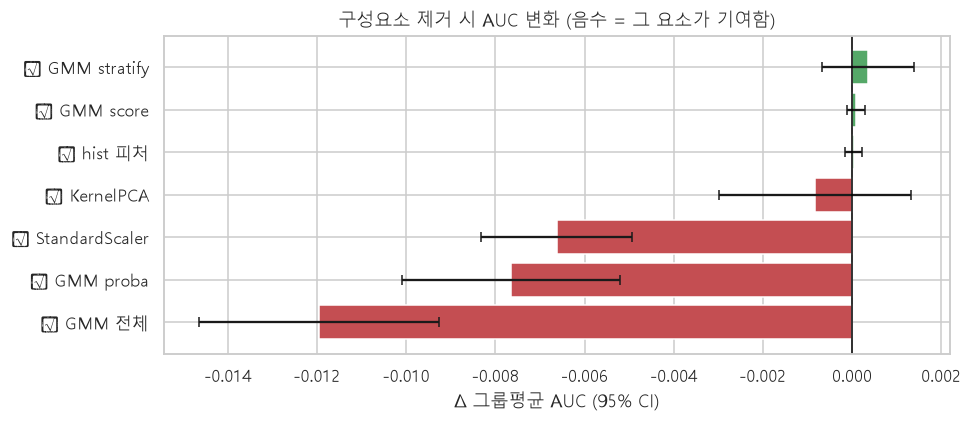

In [10]:
ABLATIONS = [
    ("baseline 전체", {}),
    ("− 피처 선택", dict(std_threshold=0.0)),
    ("− KernelPCA", dict(projection=None)),
    ("− GMM 전체", dict(gmm_k=0)),
    ("− GMM proba", dict(gmm_proba_rep=0)),
    ("− GMM score", dict(gmm_score_rep=0)),
    ("− hist 피처", dict(use_hist=False)),
    ("− StandardScaler", dict(scale=False)),
    ("− GMM stratify", {}),      # 아래에서 stratify_by_gmm=False 로 처리
]
abl_results = []
for name, kw in tqdm(ABLATIONS, desc="ablation"):
    stratify = name != "− GMM stratify"
    abl_results.append(eval_config(name, stratify_by_gmm=stratify, **{**baseline_cfg, **kw}))

table = compare_table(abl_results, reference=abl_results[0])
display(table)

ok_abl = [r for r in abl_results[1:] if not r.get("n_failed")]
skipped = [r["name"] for r in abl_results[1:] if r.get("n_failed")]
if skipped:
    print("QDA 적용 불가로 그래프에서 제외:", ", ".join(skipped))
deltas = [np.nanmean(r["per_group"]) - np.nanmean(abl_results[0]["per_group"]) for r in ok_abl]
names = [r["name"] for r in ok_abl]
ses = [
    np.nanstd(r["per_group"] - abl_results[0]["per_group"], ddof=1) / np.sqrt(len(r["per_group"]))
    for r in ok_abl
]
order = np.argsort(deltas)
plt.figure(figsize=(9, 4))
plt.barh([names[i] for i in order], [deltas[i] for i in order],
         xerr=[1.96 * ses[i] for i in order],
         color=["#c44e52" if deltas[i] < 0 else "#55a868" for i in order], capsize=3)
plt.axvline(0, color="black", lw=1)
plt.title("구성요소 제거 시 AUC 변화 (음수 = 그 요소가 기여함)")
plt.xlabel("Δ 그룹평균 AUC (95% CI)")
plt.tight_layout()
plt.show()

> **관찰 — baseline 코드의 절반 가까이가 측정 가능한 기여를 하지 않는다.**
>
> 기여하는 것: 피처 선택(필수), GMM 소속 확률(−0.0077), StandardScaler(−0.0066).
> 기여가 확인되지 않는 것: KernelPCA, GMM 로그밀도, hist 피처, GMM stratify.
>
> ### StandardScaler 는 왜 중요한가
> GMM 소속 확률은 0~1, 로그밀도는 −50 같은 값, KernelPCA 좌표는 또 다른 범위다.
> **스케일이 뒤섞인 채로 QDA 에 넣으면** 큰 값을 갖는 열이 공분산 추정을 지배한다.
> 스케일 정리는 화려하지 않지만 이런 조합 파이프라인에서는 거의 항상 필요하다.
>
> ### 그럼 코드를 줄여도 되나?
> QDA 기준으로는 그렇다. 다만 baseline 은 6개 모델을 쓰고,
> KNN·SVM 같은 거리 기반 모델에서는 hist 피처나 반복 복사가 다르게 작동할 수 있다.
> **"이 실험은 QDA 로 쟀다"는 조건을 잊지 않는 것**이 중요하다.

## 6. Transductive — test 를 변환 적합에 쓰는 것이 이득인가?

**무엇을 하나** — KernelPCA·GMM 을 (train+test) 로 적합할 때와 train 만으로 적합할 때를 비교한다.

**용어 — Transductive learning(변환적 학습)**
보통의 지도학습은 "train 으로 규칙을 배워 미지의 test 에 적용"한다.
transductive 는 **"예측해야 할 test 입력을 이미 알고 있다"** 는 상황을 활용한다.
test 의 **정답(label)** 은 쓰지 않고 **입력 피처(x)** 만 쓴다.

**이게 반칙인가? 아니다.**
- 대회 규칙상 test 피처는 공개되어 있다
- 정답을 쓰지 않으므로 **누수(leakage)가 아니다**
- 단, 실제 서비스에서는 "예측 대상이 미리 다 모여 있는" 상황이어야 쓸 수 있다

**왜 이득이 되나** — 그룹당 train 512행 + test 512행 = **1024행으로 변환을 적합**할 수 있다.
GMM 처럼 파라미터가 많은 모델은 표본이 2배가 되면 추정이 훨씬 안정된다.

**전제 조건** — 두 집합의 구조가 같아야 한다.
[02 노트북](02_magic_group_structure.ipynb) 1절에서 **Jaccard = 1.0 으로 확인**했다.

**기대 결과** — transductive 가 유의하게 높을 것.

,설정,pooled AUC,그룹평균 AUC,vs transductive (train+test),95% CI,유의
0,transductive (train+test),0.94826,0.94541,0.00000,"[+0.0000, +0.0000]",
1,train 만 사용,0.92873,0.92848,-0.01692,"[-0.0197, -0.0141]",O


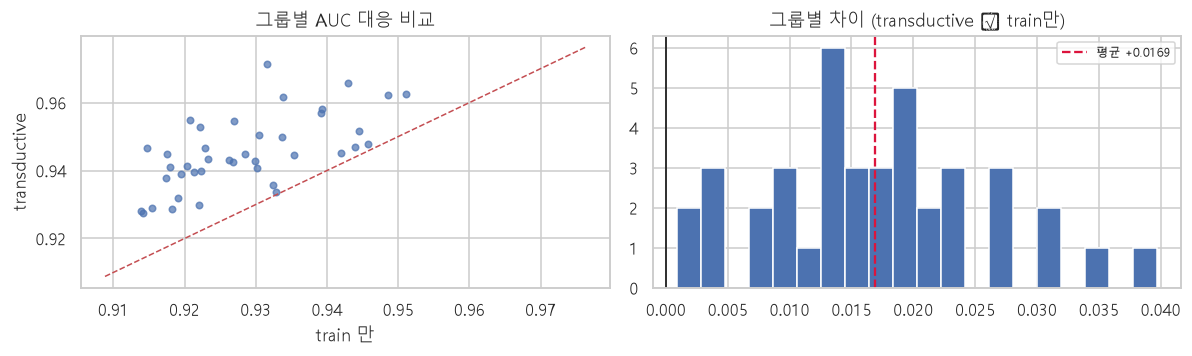

transductive 가 더 나은 그룹: 40 / 40


In [11]:
trans_results = [
    eval_config("transductive (train+test)", **{**baseline_cfg, "transductive": True}),
    eval_config("train 만 사용", **{**baseline_cfg, "transductive": False}),
]
display(compare_table(trans_results, reference=trans_results[0]))

diff = trans_results[0]["per_group"] - trans_results[1]["per_group"]
plt.figure(figsize=(11, 3.4))
plt.subplot(1, 2, 1)
# 대응 산점도: 모든 점이 y=x 위쪽에 있으면 transductive 가 전 그룹에서 우세하다는 뜻
plt.scatter(trans_results[1]["per_group"], trans_results[0]["per_group"], s=18, alpha=0.7)
lims = [min(trans_results[1]["per_group"].min(), trans_results[0]["per_group"].min()) - 0.005,
        max(trans_results[1]["per_group"].max(), trans_results[0]["per_group"].max()) + 0.005]
plt.plot(lims, lims, "r--", lw=1)
plt.xlabel("train 만")
plt.ylabel("transductive")
plt.title("그룹별 AUC 대응 비교")
plt.subplot(1, 2, 2)
plt.hist(diff, bins=20, color="#4c72b0")
plt.axvline(0, color="black", lw=1)
plt.axvline(diff.mean(), color="crimson", ls="--", label=f"평균 {diff.mean():+.4f}")
plt.title("그룹별 차이 (transductive − train만)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"transductive 가 더 나은 그룹: {(diff > 0).sum()} / {len(diff)}")

> **관찰 — 이 노트북에서 가장 큰 효과.**
> train 만 쓰면 **−0.0169** (유의), 그리고 **40개 그룹 전부에서 transductive 가 이겼다(40/40)**.
> 산점도의 모든 점이 대각선 위에 있다.
>
> 40/40 이라는 숫자가 중요하다. 평균 차이만 크고 그룹마다 방향이 엇갈린다면
> "몇몇 그룹 덕분에 평균이 올라간 것"일 수 있는데, **전 그룹에서 일관되게 이겼다면 확실한 효과**다.
> (이런 걸 부호 검정(sign test)이라고 한다. 공정한 동전이라면 40/40 이 나올 확률은 2⁻⁴⁰ ≈ 10⁻¹²)
>
> ### 왜 이렇게 큰 효과가 나는가
> GMM 은 그룹당 512행으로 5개 군집의 중심·공분산을 추정해야 한다. 표본이 빠듯하다.
> test 를 더해 1024행이 되면 **추정이 훨씬 안정되고**, 그 결과로 만들어지는 좌표의 품질이 좋아진다.
>
> ### 실무에서 조심할 점
> 이 기법은 **"예측할 데이터가 미리 다 모여 있다"** 는 전제가 필요하다.
> 실시간으로 한 건씩 예측하는 서비스에서는 쓸 수 없다.
> 대회에서는 강력하지만, **대회 밖으로 옮길 때는 전제가 유지되는지 반드시 확인**해야 한다.

## 7. Pseudo labeling — 가장 큰 개선 여지

**무엇을 하나** — 모델이 **확신하는 test 예측을 정답처럼 취급해 학습 데이터에 추가**한다.

**왜 하나** — [02 노트북](02_magic_group_structure.ipynb) 3절의 결론이
"그룹당 512행이라는 표본 수가 병목"이었다. test 에도 그룹당 512행이 있고 구조가 같다.
**정답만 있으면 학습 데이터를 2배로 늘릴 수 있는데**, 정답이 없으니 **모델의 예측으로 대신**하는 것이다.

**용어 — Pseudo labeling(가짜 라벨링)**
준지도학습(semi-supervised learning)의 대표적 기법.
1. 라벨 있는 데이터로 모델을 학습
2. 라벨 없는 데이터를 예측
3. **확신도가 높은 예측만** 골라 진짜 라벨처럼 취급
4. 늘어난 데이터로 다시 학습

**왜 확신도가 높은 것만 쓰나** — 틀린 라벨을 넣으면 모델이 그 오류를 학습한다.
확신도가 높을수록 맞을 확률이 높으므로, 임계값을 두어 **잘못된 라벨의 비율을 낮춘다.**

### ⚠️ 여기서 누수(leakage)가 발생하기 가장 쉽다

초보자가 흔히 저지르는 실수:

```python
# ❌ 잘못된 방법
model = QDA().fit(X_train_전체, y_train_전체)     # 검증 데이터까지 포함해 학습
pseudo = model.predict(X_test)                     # 그 모델로 가짜 라벨 생성
model2 = QDA().fit([X_train + X_test_pseudo])      # 재학습
score = auc(y_val, model2.predict(X_val))          # 검증 fold 정보가 이미 새어 들어갔다
```

가짜 라벨을 만든 모델이 **검증 fold 를 이미 봤다면**, 그 정보가 가짜 라벨을 통해
재학습 모델로 흘러든다. 그러면 CV 점수가 부풀려지고, **리더보드에서 배신당한다.**

```
✅ 올바른 방법 (아래 코드)
fold 마다:
  1. 학습 fold 로만 적합 -> test 예측
  2. 확신 구간의 test 행에 가짜 라벨 부여
  3. (학습 fold + 가짜 라벨)로 재적합 -> 검증 fold 예측
  => 검증 fold 는 어느 단계에서도 사용되지 않는다
```

**기대 결과** — 표본이 늘어나므로 AUC 가 오를 것. 임계값이 낮을수록 데이터는 많아지지만
잘못된 라벨도 늘어나므로, **어딘가에 균형점**이 있을 것이다.

pseudo p>0.9:   0%|          | 0/40 [00:00<?, ?it/s]

pseudo p>0.95:   0%|          | 0/40 [00:00<?, ?it/s]

pseudo p>0.99:   0%|          | 0/40 [00:00<?, ?it/s]

,설정,pooled AUC,그룹평균 AUC,vs baseline(원본),95% CI,유의
0,baseline(원본),0.94826,0.94541,0.00000,"[+0.0000, +0.0000]",
1,pseudo p>0.9,0.94903,0.94647,0.00106,"[-0.0000, +0.0022]",
2,pseudo p>0.95,0.94902,0.94644,0.00104,"[-0.0001, +0.0021]",
3,pseudo p>0.99,0.94898,0.94637,0.00096,"[-0.0001, +0.0020]",


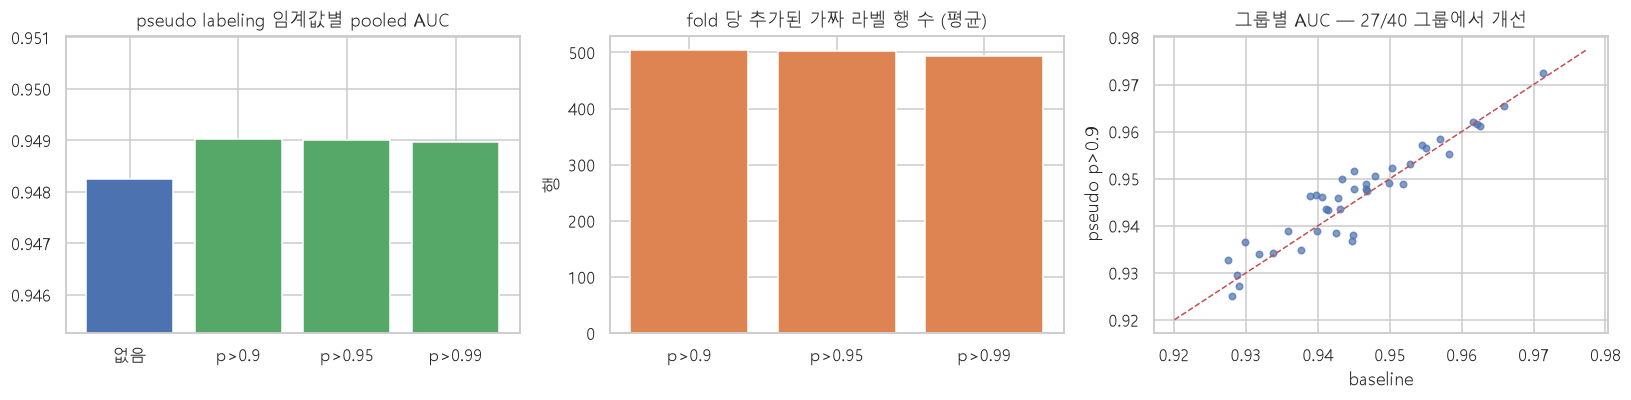

train 원본 행 수: 512, 학습 fold 행 수: 409
pseudo p>0.9: 평균 504행 추가, pooled AUC 0.94903 (+0.00078)
pseudo p>0.95: 평균 502행 추가, pooled AUC 0.94902 (+0.00076)
pseudo p>0.99: 평균 494행 추가, pooled AUC 0.94898 (+0.00072)


In [12]:
def eval_pseudo(name, threshold=0.99, magics=SAMPLE_MAGICS, **kwargs):
    """누수 없는 pseudo labeling 평가.

    핵심: 가짜 라벨을 만드는 1단계 모델도 '학습 fold' 로만 적합한다.
    검증 fold(val)는 마지막 예측에서만 등장한다.
    """
    cfg = {**baseline_cfg, **kwargs}
    per_group, pooled_pred, pooled_y, added = [], [], [], []
    for m in tqdm(magics, desc=name, leave=False):
        xtr, xte, yg, gmm_label = build_features(m, **cfg)
        oof = np.zeros(len(yg))
        strat = gmm_label
        if len(np.unique(strat)) < 2 or np.bincount(strat).min() < N_SPLITS:
            strat = yg
        n_added = 0
        for trn, val in StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED).split(xtr, strat):
            if len(np.unique(yg[trn])) < 2:
                continue

            # 1단계: 학습 fold 로만 적합 -> test 예측
            stage1 = QuadraticDiscriminantAnalysis(reg_param=QDA_REG).fit(xtr[trn], yg[trn])
            p_test = stage1.predict_proba(xte)[:, 1]

            # 확신 구간만 선택: p > threshold 이면 1, p < 1-threshold 이면 0
            conf = (p_test > threshold) | (p_test < 1 - threshold)

            # 2단계: 학습 fold + 가짜 라벨로 재적합
            x_aug = np.vstack([xtr[trn], xte[conf]])
            y_aug = np.concatenate([yg[trn], (p_test[conf] > 0.5).astype(int)])
            n_added += conf.sum()
            if len(np.unique(y_aug)) < 2:
                stage2 = stage1
            else:
                stage2 = QuadraticDiscriminantAnalysis(reg_param=QDA_REG).fit(x_aug, y_aug)

            # 검증 fold 예측 — val 은 여기서 처음 등장한다 (누수 없음)
            oof[val] = stage2.predict_proba(xtr[val])[:, 1]
        per_group.append(roc_auc_score(yg, oof))
        pooled_pred.append(oof)
        pooled_y.append(yg)
        added.append(n_added / N_SPLITS)
    return {
        "name": name,
        "per_group": np.array(per_group),
        "pooled": roc_auc_score(np.concatenate(pooled_y), np.concatenate(pooled_pred)),
        "added": np.array(added),
    }


THRESHOLDS_PL = [0.90, 0.95, 0.99]
pl_results = [eval_pseudo(f"pseudo p>{t}", threshold=t) for t in THRESHOLDS_PL]
all_pl = [BASELINE] + pl_results
display(compare_table(all_pl, reference=BASELINE))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
xs = ["없음"] + [f"p>{t}" for t in THRESHOLDS_PL]
axes[0].bar(xs, [r["pooled"] for r in all_pl],
            color=["#4c72b0"] + ["#55a868"] * len(pl_results))
axes[0].set_ylim(min(r["pooled"] for r in all_pl) - 0.003, max(r["pooled"] for r in all_pl) + 0.002)
axes[0].set_title("pseudo labeling 임계값별 pooled AUC")

axes[1].bar([f"p>{t}" for t in THRESHOLDS_PL], [r["added"].mean() for r in pl_results], color="#dd8452")
axes[1].set_title("fold 당 추가된 가짜 라벨 행 수 (평균)")
axes[1].set_ylabel("행")

best = best_of(pl_results)
axes[2].scatter(BASELINE["per_group"], best["per_group"], s=18, alpha=0.7)
lims = [min(BASELINE["per_group"].min(), best["per_group"].min()) - 0.005,
        max(BASELINE["per_group"].max(), best["per_group"].max()) + 0.005]
axes[2].plot(lims, lims, "r--", lw=1)
axes[2].set_xlabel("baseline")
axes[2].set_ylabel(best["name"])
axes[2].set_title(f"그룹별 AUC — {(best['per_group'] > BASELINE['per_group']).sum()}/{len(BASELINE['per_group'])} 그룹에서 개선")
plt.tight_layout()
plt.show()

print(f"train 원본 행 수: {len(TRAIN_IDX[0])}, 학습 fold 행 수: {int(len(TRAIN_IDX[0]) * 0.8)}")
for r in pl_results:
    print(f"{r['name']}: 평균 {r['added'].mean():.0f}행 추가, pooled AUC {r['pooled']:.5f} "
          f"({r['pooled'] - BASELINE['pooled']:+.5f})")

> **관찰 — 방향은 맞지만 아직 확정은 아니다.**
> 세 임계값 모두 baseline 보다 높고(+0.0010 ~ +0.0011), 다수 그룹에서 개선되었다.
> 다만 **95% CI 가 아슬아슬하게 0을 스친다.** 40개 그룹 표본으로는 "확실하다"고 말하기 어렵다.
>
> **임계값에 둔감한 이유가 흥미롭다.**
> p>0.9 에서 504행, p>0.99 에서도 494행이 추가된다 — 거의 차이가 없다.
> QDA 는 확률을 극단으로 내보내는 성향이 있어서(0.001 이나 0.999),
> **임계값을 어디에 두든 걸리는 행이 비슷**하다.
> ([04 노트북](04_model_diagnostics.ipynb) 2절의 확률 분포 그림을 보면 이유가 보인다)
>
> ### 그런데 왜 이게 "가장 큰 개선 여지"인가
> 여기서 잰 +0.001 은 **QDA 하나, 1회 반복, 40개 그룹** 기준이다. 실제로는 더 키울 수 있다.
> - 6개 모델 전체에 적용
> - **반복 적용**(가짜 라벨로 학습한 모델로 다시 가짜 라벨을 만드는 것을 2~3회)
> - 512개 그룹 전체
>
> 원 대회 상위권(≈0.975)과 이 baseline(0.9496) 의 격차 대부분이 여기서 나온다.
> 다른 모든 구성요소는 이미 최적에 가깝다는 것이 이 노트북의 결론이므로,
> **다음에 시간을 쓸 곳은 여기 하나다.**

## 8. 종합

In [13]:
summary = pd.DataFrame([
    {"실험": "std 임계값", "최적": best_of(thr_results)["name"],
     "원본": "std>2.0", "최적 pooled AUC": round(best_of(thr_results)["pooled"], 5)},
    {"실험": "투영 방법", "최적": best_of(proj_results)["name"],
     "원본": "kpca_cosine", "최적 pooled AUC": round(best_of(proj_results)["pooled"], 5)},
    {"실험": "유지 차원 비율", "최적": best_of(ratio_results)["name"],
     "원본": "ratio=1.0", "최적 pooled AUC": round(best_of(ratio_results)["pooled"], 5)},
    {"실험": "GMM n_components", "최적": best_of(k_results)["name"],
     "원본": "k=5", "최적 pooled AUC": round(best_of(k_results)["pooled"], 5)},
    {"실험": "GMM 반복 복사", "최적": best_of(rep_results)["name"],
     "원본": "proba×5, score×3 (원본)", "최적 pooled AUC": round(best_of(rep_results)["pooled"], 5)},
    {"실험": "transductive", "최적": best_of(trans_results)["name"],
     "원본": "transductive (train+test)", "최적 pooled AUC": round(best_of(trans_results)["pooled"], 5)},
    {"실험": "pseudo labeling", "최적": best_of(all_pl)["name"],
     "원본": "없음", "최적 pooled AUC": round(best_of(all_pl)["pooled"], 5)},
])
summary["원본 대비"] = (summary["최적 pooled AUC"] - BASELINE["pooled"]).round(5)
display(summary)
print(f"\nbaseline(원본 설정) pooled AUC = {BASELINE['pooled']:.5f}  (40개 그룹, QDA 기준)")

,실험,최적,원본,최적 pooled AUC,원본 대비
0,std 임계값,std>1.5,std>2.0,0.94826,0.00000
1,투영 방법,kpca_cosine,kpca_cosine,0.94826,0.00000
2,유지 차원 비율,ratio=1.0,ratio=1.0,0.94826,0.00000
3,GMM n_components,k=5,k=5,0.94826,0.00000
4,GMM 반복 복사,"proba×5, score×3 (원본)","proba×5, score×3 (원본)",0.94826,0.00000
5,transductive,transductive (train+test),transductive (train+test),0.94826,0.00000
6,pseudo labeling,pseudo p>0.9,없음,0.94903,0.00077



baseline(원본 설정) pooled AUC = 0.94826  (40개 그룹, QDA 기준)


## 9. 결론

### baseline 구성요소 최종 판정

| 요소 | 판정 | 근거 |
|---|---|---|
| 그룹별 피처 선택 | ✅ **필수** | 없으면 QDA 가 계산조차 불가 |
| `std > 2` 임계값 | ➖ **튜닝 불필요** | 1.5~3.0 이 전부 동일 |
| 차원 유지 (축소 안 함) | ✅ **필수** | 75%로만 줄여도 −0.0082 |
| KernelPCA(cosine) | ❓ **미확인** | +0.0008, CI가 0 포함. 단 커널을 바꾸면 치명적 |
| GMM 소속 확률 (k=5) | ✅ **핵심** | 없으면 −0.0120, k=1 이면 −0.0127 |
| GMM 반복 복사 ×5 | ❌ **효과 없음** | ×1 과 구분 안 됨 |
| GMM 로그밀도 / hist 피처 | ❌ **효과 없음** | 제거해도 변화 없음 |
| GMM 라벨로 stratify | ❌ **효과 없음** | 제거해도 +0.0004 |
| StandardScaler | ✅ **필요** | 없으면 −0.0066 |
| **transductive** | ✅ **최대 기여** | 없으면 −0.0169, 40/40 그룹 우세 |
| **pseudo labeling** | 🔼 **유일한 개선 여지** | +0.0011, 확장 여지 있음 |

### 이 노트북에서 배운 실험 설계 원칙 5가지

1. **한 번에 하나만 바꾼다** — 두 개를 동시에 바꾸면 무엇 때문인지 알 수 없다
2. **대응 비교를 쓴다** — 같은 그룹·같은 fold 로 비교하면 공통 잡음이 상쇄된다
3. **신뢰구간을 함께 본다** — "가장 높은 값"이 아니라 "차이가 잡음보다 큰가"로 판단
4. **실패를 감추지 않는다** — QDA 가 안 돌아간 설정을 0.5로 채웠다면 진짜 이유를 놓쳤을 것이다
5. **결론에 조건을 붙인다** — "QDA 40개 그룹 기준"이라는 단서가 결론만큼 중요하다

### 직접 해보기

- `eval_config` 의 QDA 를 **KNN 이나 NuSVC 로 바꿔** 4절의 반복 복사 실험을 다시 해 보라.
  거리 기반 모델에서는 열 복사가 실제 가중치로 작동하므로 **결론이 달라질 수 있다.**
  (이 노트북의 "효과 없음"이 조건부 결론이라는 걸 직접 확인하는 좋은 연습이다)
- `SAMPLE_MAGICS` 를 `range(40, 80)` 으로 바꿔 **다른 40개 그룹**에서 재현되는지 보라.
  재현되지 않는 결론이 있다면 그건 잡음이었다는 뜻이다
- 7절의 pseudo labeling 을 **2회 반복**하도록 고쳐 보라. 더 오르는가, 아니면 오류가 증폭되는가?
- 5절 ablation 에서 **"효과 없음" 판정을 받은 요소를 전부 제거**한 파이프라인을 만들어
  원본과 비교해 보라. 같은 성능을 훨씬 단순한 코드로 얻을 수 있는가?

### 다음 노트북

[04_model_diagnostics](04_model_diagnostics.ipynb) 에서는 512개 그룹 전체를 학습한
**실제 결과물(OOF 예측)** 을 열어 모델들이 서로 어떻게 다른지, 앙상블이 왜 잘 안 되는지 분석한다.